# Au-delà des PTR — le stock des divulgations dans le backtest (MathSpec)

**Objet.** Toute la chaîne S1/S2 → 05b/06/07/08/09 lit un seul type de dépôt : les PTR (`FilingType P`,
filtre câblé dans `house/digital.py:359` et `senate/digital.py:71`). Les 11 autres types n'apportent
**pas de flux frais** (délai médian ≈ 374 j, P-2′ = P-2, placebo P1 du 08 : p = 0,605) mais ils portent le
**stock** — le patrimoine déclaré (Schedule A) — que la chaîne ignore : le moteur du 05b part de h₀ = 0 et
tronque les ventes par min(q, h), alors que 33,2 % des positions de sortie étaient déjà détenues à l'entrée.

Ce notebook prépare et gouverne deux tests :
- **E1 — « ventes héritées »** : l'élu sait-il *quand vendre ce qu'il possédait déjà* ? (event study, date propre
  à 27 j — la seule hypothèse jamais couverte par 05b/06/08/09) ;
- **E2 — moteur 05b′** : les track records initialisés au patrimoine d'entrée (photos H/C) changent-ils la
  sélection top-K ? (test apparié — la valeur attendue est d'abord la *robustesse* du verdict zéro-alpha).

**Règles.**
- **Additif** : aucun notebook existant n'est modifié ; le moteur du 05b est recopié à l'identique (§1) et re-prouvé.
- **Autonome** : entrées = table clean S1/S2 + tables v1-house (sha256 vérifiés contre `MANIFEST.json`) + caches
  prix. Zéro constante héritée sans re-preuve.
- **Anti-look-ahead** : toute ligne du dépôt d n'existe qu'à t ≥ FilingDate(d) — ℱₜ = σ({d : FilingDate(d) ≤ t}).
  Une photo « au 31/12 » déposée en août N+1 n'est jouable qu'en août N+1.
- **Anti-data-mining** : seuils (§2) et protocoles (§3, §4) écrits et GELÉS avant tout résultat ; placebos ;
  verdicts mécaniques.
- **Périmètre** : House uniquement (le Sénat n'a aucune ingestion non-P) ; les lignes Sénat de la table clean
  restent dans le moteur pour garantir la non-régression.

**Plan.** §0 données et harmonisation · §1 copie exacte du moteur 05b + oracles · §2 gates T0 (pré-enregistrés)
· §3 pré-enregistrement E1 · §4 pré-enregistrement E2 · §5 résultats — *ouverts seulement après validation du
pré-enregistrement (point d'arrêt ②)*.

## 0. Données : chargement contrôlé et harmonisation

Trois sources, chacune contrôlée à l'octet ou re-prouvée :
1. les **tables v1-house** (`01_v1_house/cache/tables/`, rapatriées par checkout partiel depuis la branche
   `v1-house`) — chaque fichier est vérifié par sha256 contre `MANIFEST.json` (assert bloquant) ;
2. la **table clean S1/S2** (`data/clean/transactions_backtest_2014_2026.csv`, 134 464 × 36) — celle du 05b ;
3. les **prix** : `cache/prices_v2` (l'univers du 05b, jamais modifié — snapshot re-asserté en fin de notebook)
   et `cache/prices_holdings_v1` (cache **séparé** pour les tickers de photos ; ajouter des séries à `prices_v2`
   ferait dépasser l'oracle 118 029 du 05b/07 au prochain run).

In [1]:
import pandas as pd, numpy as np, hashlib, json, os, glob, re
import matplotlib.pyplot as plt

J     = "/Users/lemairealice/Downloads/Jupiter"
BASE  = os.path.join(J, "00. S3S4 en cours")
V1T   = os.path.join(J, "01_v1_house", "cache", "tables")
CLEAN = os.path.join(J, "00_S1S2_donnees", "data", "clean", "transactions_backtest_2014_2026.csv")
MAN   = json.load(open(os.path.join(J, "01_v1_house", "cache", "MANIFEST.json")))

# sha256 bloquants : la provenance des tables v1 est prouvée, pas supposée
_V1 = ["04_transactions_v1.csv", "07_transactions_ptr_ocr.csv", "11_holdings_complets.csv",
       "12_portefeuilles_dates.csv", "13_recalages.csv", "14_registre_membres.csv",
       "15_portefeuille_entree.csv", "16_flux_oat_net.csv", "17_recalages_oat.csv",
       "18_churn_decompose.csv"]
for f in _V1:
    h = hashlib.sha256(open(os.path.join(V1T, f), "rb").read()).hexdigest()
    assert h == MAN["sha_tables"][f], f"sha divergent : {f}"
print(f"{len(_V1)} tables v1-house conformes au MANIFEST (sha256)")
print("comptes gelés v1 :", {k: MAN["comptes"][k] for k in
      ("recensement", "transactions_v1", "transactions_signal_ptr", "holdings_v1")})

10 tables v1-house conformes au MANIFEST (sha256)
comptes gelés v1 : {'recensement': 35377, 'transactions_v1': 166149, 'transactions_signal_ptr': 56002, 'holdings_v1': 198615}


In [2]:
# Chargements (usecols stricts : on ne lit que ce qui sert)
e15  = pd.read_csv(os.path.join(V1T, "15_portefeuille_entree.csv"), parse_dates=["filing_date"])
h11  = pd.read_csv(os.path.join(V1T, "11_holdings_complets.csv"), low_memory=False,
                   usecols=["doc_id", "bioguide", "filing_type", "filing_date", "ticker",
                            "value_lo", "value_hi", "conteneur_nu", "classe"],
                   parse_dates=["filing_date"])
h11["mid"] = (h11["value_lo"] + h11["value_hi"]) / 2
ph12 = pd.read_csv(os.path.join(V1T, "12_portefeuilles_dates.csv"), parse_dates=["filing_date"])
r13  = pd.read_csv(os.path.join(V1T, "13_recalages.csv"))
r17  = pd.read_csv(os.path.join(V1T, "17_recalages_oat.csv"))
f16  = pd.read_csv(os.path.join(V1T, "16_flux_oat_net.csv"), low_memory=False,
                   parse_dates=["transaction_date", "disclosure_date"])
reg14 = pd.read_csv(os.path.join(V1T, "14_registre_membres.csv"))
f04  = pd.read_csv(os.path.join(V1T, "04_transactions_v1.csv"), low_memory=False,
                   usecols=["provenance", "bioguide", "ticker", "operation_type", "transaction_date"],
                   parse_dates=["transaction_date"])
ocr07 = pd.read_csv(os.path.join(V1T, "07_transactions_ptr_ocr.csv"), low_memory=False,
                    usecols=["bioguide", "ticker", "operation_type", "transaction_date"],
                    parse_dates=["transaction_date"])
print(f"15_portefeuille_entree : {len(e15)} photos d'entrée ({dict(e15['type_photo'].value_counts())})")
print(f"11_holdings_complets   : {len(h11):,} lignes | 16_flux_oat_net : {len(f16):,} "
      f"| 12_portefeuilles_dates : {len(ph12):,}")
print(f"04 (ptr élec) : {(f04['provenance']=='ptr').sum():,} | 07 (ptr OCR) : {len(ocr07):,} "
      f"— flux PTR v1 total {(f04['provenance']=='ptr').sum() + len(ocr07):,}")

15_portefeuille_entree : 284 photos d'entrée ({'H': np.int64(252), 'C': np.int64(32)})
11_holdings_complets   : 420,916 lignes | 16_flux_oat_net : 26,115 | 12_portefeuilles_dates : 279,717
04 (ptr élec) : 56,002 | 07 (ptr OCR) : 105,074 — flux PTR v1 total 161,076


In [3]:
# Harmonisation 1 — clé membre : `bioguide` (v1) ≡ `bioguide_id` (clean). Preuve : zéro orphelin.
cl_meta = pd.read_csv(CLEAN, low_memory=False,
                      usecols=["bioguide_id", "chamber", "ticker", "ticker_yahoo",
                               "amount_range", "amount_midpoint"])
_house_bids = set(cl_meta.loc[cl_meta["chamber"] == "house", "bioguide_id"])
_orphelins = _house_bids - set(reg14["bioguide"])
assert not _orphelins, f"bioguide_id House absents du registre v1 : {_orphelins}"
print(f"clé membre : {len(_house_bids)} bioguide_id House de la table clean, tous dans le registre des 900 — 0 orphelin")

# Harmonisation 2 — tickers : map ticker→ticker_yahoo RECONSTRUITE depuis la table clean (0 constante héritée)
_paires = cl_meta[["ticker", "ticker_yahoo"]].dropna().drop_duplicates()
_conflits = _paires.groupby("ticker")["ticker_yahoo"].nunique()
assert (_conflits <= 1).all(), f"map ticker→yahoo ambiguë : {_conflits[_conflits > 1].index.tolist()}"
MAP_YAHOO = dict(zip(_paires["ticker"], _paires["ticker_yahoo"]))
def to_yahoo(t):
    t = str(t)
    return MAP_YAHOO.get(t, t.replace(".", "-"))
_ren = sum(1 for k, v in MAP_YAHOO.items() if k != v)
print(f"map tickers : {len(MAP_YAHOO)} paires, {_ren} renommages (FB→META…), 0 conflit ; défaut = '.'→'-'")

# Harmonisation 3 — fourchettes : re-preuve (v1 mid conventionnel ≡ clean amount_midpoint, par amount_range)
_g_clean = (cl_meta.dropna(subset=["amount_range", "amount_midpoint"])
            .groupby("amount_range")["amount_midpoint"].agg(["nunique", "first"]))
assert (_g_clean["nunique"] == 1).all(), "amount_midpoint non déterministe par fourchette dans la table clean"
_v1_mid = (f16.dropna(subset=["amount_range"])
           .assign(mid=lambda d: (d["amount_lo"] + d["amount_hi"]) / 2)
           .groupby("amount_range")["mid"].agg(["nunique", "first"]))
_commun = _g_clean.index.intersection(_v1_mid.index)
_ecart = (_g_clean.loc[_commun, "first"] - _v1_mid.loc[_commun, "first"]).abs().max()
print(f"fourchettes : {len(_commun)} amount_range communs clean↔v1, écart max des milieux = {_ecart} "
      f"{'✅' if _ecart == 0 else '⚠️ à investiguer'}")
assert _ecart == 0

clé membre : 315 bioguide_id House de la table clean, tous dans le registre des 900 — 0 orphelin
map tickers : 4653 paires, 52 renommages (FB→META…), 0 conflit ; défaut = '.'→'-'
fourchettes : 12 amount_range communs clean↔v1, écart max des milieux = 0.0 ✅


In [4]:
# Garde-fous périmètre — snapshot de prices_v2 (re-asserté en toute fin) + journal des exclusions connues
PRICES_V2 = os.path.join(BASE, "cache", "prices_v2")
_SNAP_PV2 = sorted(os.listdir(PRICES_V2))
print(f"snapshot prices_v2 : {len(_SNAP_PV2)} fichiers (le notebook s'interdit d'y toucher)")

_docs_perdus = sorted(set(e15["doc_id"]) - set(h11["doc_id"]))
print(f"journal : photos d'entrée sans holdings dans la table 11 → {_docs_perdus} "
      f"(attendu : [10041638], 1 doc H à 1 ticker — exclu, tracé)")
assert _docs_perdus == [10041638]

snapshot prices_v2 : 3351 fichiers (le notebook s'interdit d'y toucher)
journal : photos d'entrée sans holdings dans la table 11 → [10041638] (attendu : [10041638], 1 doc H à 1 ticker — exclu, tracé)


### 0.1 Validation §0
Quatre preuves : (i) 10 sha256 conformes au MANIFEST ; (ii) 0 bioguide orphelin entre la table clean House
et le registre v1 des 900 ; (iii) map ticker→yahoo sans conflit, milieux de fourchettes identiques clean↔v1
(écart max 0) ; (iv) snapshot de `prices_v2` gelé et 1 doc perdu journalisé. Tout est asserté — une
divergence arrête le notebook.

## 1. Le moteur du 05b, recopié à l'identique

Pattern du 07/09 : les cellules du 05b sont recopiées **verbatim** (en-têtes « COPIE EXACTE » conservés),
jamais redéfinies ; le moteur étendu de E2 (§4) vivra sous des noms neufs (`member_shares_v2`, …) et son mode
témoin devra reproduire ces objets **bit-à-bit**. L'oracle (§1.1) fige les quatre compteurs du 05b.

In [5]:
# === COPIE EXACTE 05b — cellule 2 (ne pas modifier : garantit l'équivalence) ===
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [6]:
# === COPIE EXACTE 05b — cellule 3 (ne pas modifier : garantit l'équivalence) ===
# Table PROPRE canonique S1/S2 (source-primaire) -> noms alignés sur la mécanique du 05.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")
_n2013 = int((df["traded"].dt.year == 2013).sum())
print(f"dont {_n2013} trades exécutés en 2013 (déclarés dans des dépôts 2014+) — gardés : chaque coupe classe sur tout l'historique ≤ 31/12/Y")

134464 -> 134429 trades  |  372 membres  |  4618 tickers
dont 743 trades exécutés en 2013 (déclarés dans des dépôts 2014+) — gardés : chaque coupe classe sur tout l'historique ≤ 31/12/Y


In [7]:
# === COPIE EXACTE 05b — cellule 5 (ne pas modifier : garantit l'équivalence) ===
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [8]:
# === COPIE EXACTE 05b — cellule 6 (ne pas modifier : garantit l'équivalence) ===
# Télécharge les prix ABSENTS du cache (resumable ; cache complet => 0 => hors-ligne)
import yfinance as yf, time, logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
os.makedirs(PRICES, exist_ok=True)
have0  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
fail_f = os.path.join(PRICES, "failed_v2.csv")
failed = set(pd.read_csv(fail_f)["ticker"]) if os.path.exists(fail_f) else set()
todo   = [t for t in dict.fromkeys(df["ticker"]) if isinstance(t, str) and t not in have0 and t not in failed]
print(f"cache: {len(have0)} tickers | délistés/échecs connus sautés: {len(set(df['ticker']) & failed)} | à télécharger: {len(todo)}")
new_fail = []
for i in range(0, len(todo), 60):
    chunk = todo[i:i+60]
    try:
        data = yf.download(chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                           progress=False, threads=True, group_by="ticker")
    except Exception as e:
        print("  batch KO:", str(e)[:60]); data = None
    for t in chunk:
        s = None
        try:
            if data is not None and isinstance(data.columns, pd.MultiIndex):
                if t in data.columns.get_level_values(0):
                    s = data[t]["Close"].dropna()
            elif data is not None and "Close" in getattr(data, "columns", []):
                s = data["Close"].dropna()
        except Exception:
            s = None
        if s is None or len(s) < 20:
            new_fail.append(t)
        else:
            s.rename("close").to_csv(os.path.join(PRICES, t + ".csv"))
    time.sleep(0.4)
if new_fail:
    pd.DataFrame({"ticker": new_fail, "classe": "inattendu"}).to_csv(fail_f, mode="a", header=not os.path.exists(fail_f), index=False)
print(f"téléchargés OK: {len(todo) - len(new_fail)} | nouveaux échecs: {len(new_fail)}")

cache: 3350 tickers | délistés/échecs connus sautés: 1268 | à télécharger: 0
téléchargés OK: 0 | nouveaux échecs: 0


In [9]:
# === COPIE EXACTE 05b — cellule 7 (ne pas modifier : garantit l'équivalence) ===
# Charge les prix utiles, alignés sur le calendrier ; garde-fou anti-corruption Yahoo
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


In [10]:
# === COPIE EXACTE 05b — cellule 9 (ne pas modifier : garantit l'équivalence) ===
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [11]:
# === COPIE EXACTE 05b — cellule 14 (ne pas modifier : garantit l'équivalence) ===
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [12]:
# === COPIE EXACTE 05b — cellule 10 (ne pas modifier : garantit l'équivalence) ===
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Nancy Pelosi"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

In [13]:
# === COPIE EXACTE 05b — cellule 16 (ne pas modifier : garantit l'équivalence) ===
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


### 1.1 Validation — oracle du 05b
Les quatre compteurs gelés du 05b/07 : 118 029 trades exploitables · 3 289 tickers avec prix · 266 séries de
rendement · 223 éligibles (n_trades ≥ 10 et n_jours ≥ 126).

In [14]:
# Oracle (i) — compteurs gelés du 05b
assert len(df) == 118029, len(df)
assert len(need) == 3289, len(need)
assert len(wf_ret) == 266, len(wf_ret)
_elig = [b for b in wf_ret if len(wf_traded[b]) >= 10 and len(wf_ret[b]) >= 126]
assert len(_elig) == 223, len(_elig)
print(f"(i) compteurs gelés OK : {len(df)} trades | {len(need)} tickers | {len(wf_ret)} membres | {len(_elig)} éligibles")

(i) compteurs gelés OK : 118029 trades | 3289 tickers | 266 membres | 223 éligibles


## 2. T0 — la batterie de gates, pré-enregistrée

**GEL — seuils écrits avant l'exécution des cellules qui suivent.** Chaque gate décide mécaniquement de
l'ouverture ou de la fermeture d'une branche du programme ; une fermeture est un livrable, pas un échec.

| gate | mesure | règle de décision |
|---|---|---|
| (a) | P-2 restreint aux clés-**ticker** (moteur photo→photo rejoué, mêmes règles que §21.1 v1, clés `[A-Z][A-Z0-9.\-]{0,5}`) | ≥ 85 % → h₀ défendable tel quel (recalage O = audit) ; 70–85 % → recalage O **obligatoire** dans E2 ; < 70 % → E2-h₀ fermé |
| (b) | part des recalages dont n_confirmées bouge quand on ajoute le flux O/A/T (13 vs 17, population du P-2 : arrivées C exclues) | < 5 % → run F (flux O/A/T) fermé définitivement ; ≥ 5 % → run F reste dans l'ablation |
| (c) | cohorte C = photos d'entrée ∩ éligibles 05b | ≥ 30 membres, sinon E2-h₀ fermé (aucun pouvoir sur le classement) |
| (d) | puissance ex ante : MDE du critère NAV top-K et borne de la MDE du ΔIC | publication obligatoire avant résultats ; si MDE(NAV) > 5 %/an, le jugement E2 se fait au **niveau classement** (ΔIC apparié), jamais sur la NAV |
| (e) | concentration des photos d'entrée : HHI des poids mid, part de la plus grosse ligne | descriptif contraignant : si la part max médiane > 25 %, la sensibilité {lo, mid, hi} est **obligatoire** sur tout résultat E2 |
| (f) | couverture prix des photos d'entrée, **en valeur**, après complément du cache séparé | publiée ; si < 80 % en valeur, le biais de survie est documenté sur chaque résultat E2 |
| (g) | stock agrégé : part de la valeur tickérisée ; part de la valeur en fourchettes ≥ 1 M$ (ratio 5×) ; persistance φ | « copier le stock agrégé » exige valeur tickérisée ≥ 50 % **et** poids non dominés par les conventions ; sinon fermé (une cellule descriptive, pas de backtest) |

Rappels de contexte (mesurés en amont, re-calculés ici) : P-2 toutes clés = 66,7 % ; ~74 % du churn
photo→photo vient de clés-nom instables ; le flux net O/A/T (26 115) a un délai médian de 374 j.

In [15]:
# T0(a) — le moteur photo→photo de §21.1 v1, rejoué sur les seules clés-TICKER
# Règles identiques à la cellule 94 de V1_House : état = photo précédente ∪ achats − (ventes − achats)
# entre les deux dates ; confirmation = photo ∩ reconstruit ; arrivées C exclues de la stat.
RE_TICKER = r"[A-Z][A-Z0-9.\-]{0,5}"

_ph_t = ph12[ph12["cle"].astype(str).str.fullmatch(RE_TICKER).fillna(False)]
_sig  = f04[f04["provenance"] == "ptr"]
_flux = pd.concat([_sig[["bioguide", "ticker", "operation_type", "transaction_date"]],
                   ocr07[["bioguide", "ticker", "operation_type", "transaction_date"]]])
_flux = _flux[_flux["bioguide"].notna() & _flux["transaction_date"].notna() & _flux["ticker"].notna()]
_flux = _flux[_flux["ticker"].astype(str).str.fullmatch(RE_TICKER).fillna(False)].copy()
_flux["cle"]   = _flux["ticker"]
_flux["achat"] = _flux["operation_type"].astype(str).str.startswith("Purchase")

def _moteur_photo_flux(photos, fluxdf):
    rows, fg = [], dict(tuple(fluxdf.groupby("bioguide")))
    for b, p in photos.groupby("bioguide"):
        dates = sorted(p["filing_date"].unique())
        if len(dates) < 2:
            continue
        fx, etat, d_prec = fg.get(b), None, None
        for d in dates:
            photo  = set(p.loc[p["filing_date"] == d, "cle"])
            ftypes = "+".join(sorted(p.loc[p["filing_date"] == d, "filing_type"].unique()))
            if etat is not None:
                rec = set(etat)
                if fx is not None:
                    w = fx[(fx["transaction_date"] > d_prec) & (fx["transaction_date"] <= d)]
                    rec |= set(w.loc[w["achat"], "cle"])
                    rec -= set(w.loc[~w["achat"], "cle"]) - set(w.loc[w["achat"], "cle"])
                rows.append(dict(bioguide=b, date=d, ftype=ftypes, n_photo=len(photo),
                                 n_confirmees=len(photo & rec)))
            etat, d_prec = set(photo), d
    return pd.DataFrame(rows)

# contrôle : la réplique TOUTES CLÉS de la règle officielle redonne le P-2 publié (66,7 %)
_suiv13 = r13[r13["n_confirmees"].notna() & ~r13["ftype"].str.contains("C")]
_p2_off = (_suiv13["n_confirmees"] / _suiv13["n_photo"]).median()
print(f"contrôle : P-2 officiel répliqué depuis 13_recalages = {_p2_off*100:.1f} % ({len(_suiv13)} recalages)")
assert round(_p2_off * 100, 1) == 66.7

_rec_t  = _moteur_photo_flux(_ph_t, _flux)
_suiv_t = _rec_t[(_rec_t["n_photo"] > 0) & ~_rec_t["ftype"].str.contains("C")]
_taux_t = _suiv_t["n_confirmees"] / _suiv_t["n_photo"]
P2_TICKER = _taux_t.median() * 100
print(f"T0(a)  P-2_ticker = {P2_TICKER:.1f} %  (médiane sur {len(_suiv_t)} recalages, "
      f"{_suiv_t['bioguide'].nunique()} membres ; q25 {_taux_t.quantile(.25)*100:.0f} % · "
      f"q75 {_taux_t.quantile(.75)*100:.0f} %)")
_verdict_a = ("h₀ défendable tel quel (recalage O = audit)" if P2_TICKER >= 85 else
              "recalage O OBLIGATOIRE dans E2" if P2_TICKER >= 70 else "E2-h₀ FERMÉ")
print(f"→ gate (a) : {_verdict_a}")

contrôle : P-2 officiel répliqué depuis 13_recalages = 66.7 % (4752 recalages)


T0(a)  P-2_ticker = 94.1 %  (médiane sur 3748 recalages, 736 membres ; q25 67 % · q75 100 %)
→ gate (a) : h₀ défendable tel quel (recalage O = audit)


In [16]:
# T0(b) — le flux O/A/T bouge-t-il les recalages ? (13 vs 17, population du P-2)
_j = (r13.merge(r17, on=["bioguide", "date", "ftype", "n_photo"], suffixes=("_p2", "_p2p"))
         .dropna(subset=["n_confirmees_p2"]))
_j = _j[~_j["ftype"].str.contains("C")]
_delta = _j["n_confirmees_p2p"] - _j["n_confirmees_p2"]
PART_BOUGE = (_delta != 0).mean() * 100
print(f"T0(b)  {len(_j)} recalages joints | bougés avec le flux O/A/T : {(_delta != 0).sum()} "
      f"({PART_BOUGE:.1f} %) | gain net de positions confirmées : {int(_delta.sum()):+d}")
print(f"→ gate (b) : {'run F (flux O/A/T) reste dans l’ablation E2' if PART_BOUGE >= 5 else 'run F fermé définitivement'}")
print("   (nota : la médiane P-2′ = P-2 = 66,7 % masque cette queue — les deltas sont des deux signes)")

T0(b)  4752 recalages joints | bougés avec le flux O/A/T : 821 (17.3 %) | gain net de positions confirmées : +1424
→ gate (b) : run F (flux O/A/T) reste dans l’ablation E2
   (nota : la médiane P-2′ = P-2 = 66,7 % masque cette queue — les deltas sont des deux signes)


In [17]:
# T0(c) — la cohorte : photos d'entrée ∩ éligibles 05b
_elig = [b for b in wf_ret if len(wf_traded[b]) >= 10 and len(wf_ret[b]) >= 126]
C_ENTREE = sorted(set(e15["bioguide"]) & set(_elig))
print(f"T0(c)  photos d'entrée {len(e15)} | ∩ traders de la table clean : "
      f"{len(set(e15['bioguide']) & set(df['bioguide_id']))} | ∩ 223 éligibles 05b : {len(C_ENTREE)}")
print(f"→ gate (c) : {'OUVERT' if len(C_ENTREE) >= 30 else 'E2-h₀ FERMÉ'} (seuil 30) — "
      f"E2 ne touche que {len(C_ENTREE)}/{len(_elig)} éligibles : le top-K mixte est interdit, "
      f"le jugement est apparié intra-membre")

T0(c)  photos d'entrée 284 | ∩ traders de la table clean : 122 | ∩ 223 éligibles 05b : 73
→ gate (c) : OUVERT (seuil 30) — E2 ne touche que 73/223 éligibles : le top-K mixte est interdit, le jugement est apparié intra-membre


In [18]:
# T0(d) — puissance ex ante (publiée AVANT tout résultat)
_ex_ann = []
for _b in C_ENTREE:
    _r = wf_ret[_b]
    _x = (_r - r_spy.reindex(_r.index)).dropna()
    if len(_x) > 252:
        _ex_ann.append(_x.mean() * 252)
_sigma_x = np.std(_ex_ann)
# NAV top-K : n = 11 excès annuels, test t unilatéral 5 %, puissance 80 %
_MDE_NAV = (1.812 + 0.883) * 0.09 / np.sqrt(11)
print(f"T0(d)  dispersion cross-membres des excès annualisés (cohorte, n={len(_ex_ann)}) : σ = {_sigma_x*100:.1f} %/an")
print(f"       MDE du critère NAV top-K (n = 11 ans, σ ≈ 9 %/an, α 5 % unilatéral, puissance 80 %) "
      f"≈ {_MDE_NAV*100:.1f} %/an")
print(f"       borne (non appariée) de la MDE du ΔIC : SE_Fisher = 1/√(n−3) = {1/np.sqrt(len(C_ENTREE)-3):.3f} ; "
      f"l'appariement partage le bruit v0/v1 → la MDE appariée exacte (bootstrap) est publiée en §5 avant dévoilement")
print(f"→ gate (d) : MDE(NAV) = {_MDE_NAV*100:.1f} %/an > 5 %/an → le jugement E2 se fait au NIVEAU CLASSEMENT "
      f"(ΔIC apparié), jamais sur la NAV finale — règle actée")

T0(d)  dispersion cross-membres des excès annualisés (cohorte, n=72) : σ = 14.6 %/an
       MDE du critère NAV top-K (n = 11 ans, σ ≈ 9 %/an, α 5 % unilatéral, puissance 80 %) ≈ 7.3 %/an
       borne (non appariée) de la MDE du ΔIC : SE_Fisher = 1/√(n−3) = 0.120 ; l'appariement partage le bruit v0/v1 → la MDE appariée exacte (bootstrap) est publiée en §5 avant dévoilement
→ gate (d) : MDE(NAV) = 7.3 %/an > 5 %/an → le jugement E2 se fait au NIVEAU CLASSEMENT (ΔIC apparié), jamais sur la NAV finale — règle actée


In [19]:
# T0(e) — concentration des photos d'entrée (le risque « NAV d'une convention »)
_ent   = e15.merge(h11, on="doc_id", suffixes=("", "_h"))
_ent_t = _ent[_ent["ticker"].notna() & ~_ent["conteneur_nu"] & _ent["mid"].notna()].copy()
_ent_t["yh"] = _ent_t["ticker"].map(to_yahoo)
_g    = _ent_t.groupby("bioguide")
_hhi  = _g.apply(lambda x: ((x["mid"] / x["mid"].sum()) ** 2).sum(), include_groups=False)
_bmax = _g.apply(lambda x: x["mid"].max() / x["mid"].sum(), include_groups=False)
print(f"T0(e)  {len(_ent_t):,} holdings tickérisés valorisés sur {_ent['doc_id'].nunique()}/284 photos d'entrée")
print(f"       HHI des poids mid par membre : médiane {_hhi.median():.2f} · q75 {_hhi.quantile(.75):.2f}")
print(f"       part de la plus grosse ligne : médiane {_bmax.median()*100:.0f} % · q75 {_bmax.quantile(.75)*100:.0f} %")
print(f"→ gate (e) : part max médiane {'>' if _bmax.median() > .25 else '≤'} 25 % → sensibilité "
      f"{{lo, mid, hi}} {'OBLIGATOIRE' if _bmax.median() > .25 else 'recommandée'} sur tout résultat E2")

T0(e)  12,199 holdings tickérisés valorisés sur 283/284 photos d'entrée
       HHI des poids mid par membre : médiane 0.21 · q75 0.55
       part de la plus grosse ligne : médiane 33 % · q75 72 %
→ gate (e) : part max médiane > 25 % → sensibilité {lo, mid, hi} OBLIGATOIRE sur tout résultat E2


In [20]:
# T0(f) — couverture prix des photos d'entrée, EN VALEUR, avec le cache séparé
# (pattern resumable du 05b : cache complet ⇒ 0 téléchargement ; prices_v2 JAMAIS touché)
PRICES_HOLD = os.path.join(BASE, "cache", "prices_holdings_v1")
os.makedirs(PRICES_HOLD, exist_ok=True)
_have_v2  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_V2, "*.csv"))} - {"failed_v2"}
_have_ph  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}
_fail_f   = os.path.join(PRICES_HOLD, "failed_holdings_v1.csv")
_failed   = set(pd.read_csv(_fail_f)["ticker"]) if os.path.exists(_fail_f) else set()
_bids_utiles = set(C_ENTREE) | set(e15["bioguide"])
_t_photos = {to_yahoo(t) for t in h11.loc[h11["ticker"].notna() & ~h11["conteneur_nu"]
                                          & h11["bioguide"].isin(_bids_utiles), "ticker"]}
_todo = sorted(_t_photos - _have_v2 - _have_ph - _failed)
print(f"tickers de photos (cohorte + entrées) : {len(_t_photos)} | dans prices_v2 : {len(_t_photos & _have_v2)} "
      f"| cache séparé : {len(_t_photos & _have_ph)} | échecs connus : {len(_t_photos & _failed)} | à télécharger : {len(_todo)}")
if _todo:
    import yfinance as yf, logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)
    _new_fail = []
    for _i in range(0, len(_todo), 60):
        _chunk = _todo[_i:_i + 60]
        try:
            _data = yf.download(_chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                                progress=False, threads=True, group_by="ticker")
        except Exception as _e:
            print("  batch KO :", str(_e)[:60]); _data = None
        for _t in _chunk:
            _s = None
            try:
                if _data is not None and isinstance(_data.columns, pd.MultiIndex):
                    if _t in _data.columns.get_level_values(0):
                        _s = _data[_t]["Close"].dropna()
                elif _data is not None and "Close" in getattr(_data, "columns", []):
                    _s = _data["Close"].dropna()
            except Exception:
                _s = None
            if _s is not None and len(_s) >= 2:
                _s.rename("close").to_csv(os.path.join(PRICES_HOLD, _t + ".csv"), index_label="Date")
            else:
                _new_fail.append(_t)
    if _new_fail:
        _old = pd.read_csv(_fail_f) if os.path.exists(_fail_f) else pd.DataFrame(columns=["ticker"])
        pd.concat([_old, pd.DataFrame({"ticker": _new_fail})]).drop_duplicates().to_csv(_fail_f, index=False)
    _have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}

_ent_t["prix_ok"] = _ent_t["yh"].isin(_have_v2 | _have_ph)
_cov_l = _ent_t["prix_ok"].mean() * 100
_cov_v = _ent_t.loc[_ent_t["prix_ok"], "mid"].sum() / _ent_t["mid"].sum() * 100
_c73   = _ent_t[_ent_t["bioguide"].isin(C_ENTREE)]
_cov_v73 = _c73.loc[_c73["prix_ok"], "mid"].sum() / _c73["mid"].sum() * 100
print(f"T0(f)  couverture prix des photos d'entrée : {_cov_l:.1f} % des lignes | {_cov_v:.1f} % de la valeur "
      f"(cohorte C : {_cov_v73:.1f} % de la valeur)")
print(f"→ gate (f) : {'OK' if _cov_v >= 80 else 'BIAIS DE SURVIE À DOCUMENTER sur chaque résultat E2'} (seuil 80 % en valeur)")

tickers de photos (cohorte + entrées) : 5745 | dans prices_v2 : 2402 | cache séparé : 1189 | échecs connus : 1436 | à télécharger : 718


T0(f)  couverture prix des photos d'entrée : 85.6 % des lignes | 76.4 % de la valeur (cohorte C : 79.9 % de la valeur)
→ gate (f) : BIAIS DE SURVIE À DOCUMENTER sur chaque résultat E2 (seuil 80 % en valeur)


In [21]:
# T0(g) — le stock agrégé : fermeture attendue de « copier le stock »
_hv = h11[~h11["conteneur_nu"] & h11["mid"].notna()]
_tick = _hv["ticker"].notna()
_v_tot, _v_tick = _hv["mid"].sum(), _hv.loc[_tick, "mid"].sum()
_part_tick = _v_tick / _v_tot * 100
_part_gros = _hv.loc[_hv["value_hi"] >= 1_000_000, "mid"].sum() / _v_tot * 100
_phis = []
for _b, _p in _ph_t.groupby("bioguide"):
    _dates = sorted(_p["filing_date"].unique())
    for _d0, _d1 in zip(_dates, _dates[1:]):
        _s0 = set(_p.loc[_p["filing_date"] == _d0, "cle"]); _s1 = set(_p.loc[_p["filing_date"] == _d1, "cle"])
        if _s0:
            _phis.append(len(_s0 & _s1) / len(_s0))
print(f"T0(g)  valeur déclarée {_v_tot/1e9:.1f} Md$ | tickérisée {_v_tick/1e9:.1f} Md$ = {_part_tick:.1f} % "
      f"(seuil 50 %)")
print(f"       valeur en fourchettes ≥ 1 M$ (ratio hi/lo = 5×) : {_part_gros:.1f} % → les poids seraient des conventions")
print(f"       persistance φ (position ticker tenue photo→photo, {len(_phis)} paires) : "
      f"médiane {np.median(_phis)*100:.1f} % — le stock est lent, mais l'assiette est inobservable")
print(f"→ gate (g) : « copier le stock agrégé » {'FERMÉ' if _part_tick < 50 else 'ouvert'} — "
      f"cette cellule EST le livrable descriptif ; aucun backtest de niveau ne sera construit")

T0(g)  valeur déclarée 82.2 Md$ | tickérisée 14.7 Md$ = 17.8 % (seuil 50 %)
       valeur en fourchettes ≥ 1 M$ (ratio hi/lo = 5×) : 76.6 % → les poids seraient des conventions
       persistance φ (position ticker tenue photo→photo, 4009 paires) : médiane 97.6 % — le stock est lent, mais l'assiette est inobservable
→ gate (g) : « copier le stock agrégé » FERMÉ — cette cellule EST le livrable descriptif ; aucun backtest de niveau ne sera construit


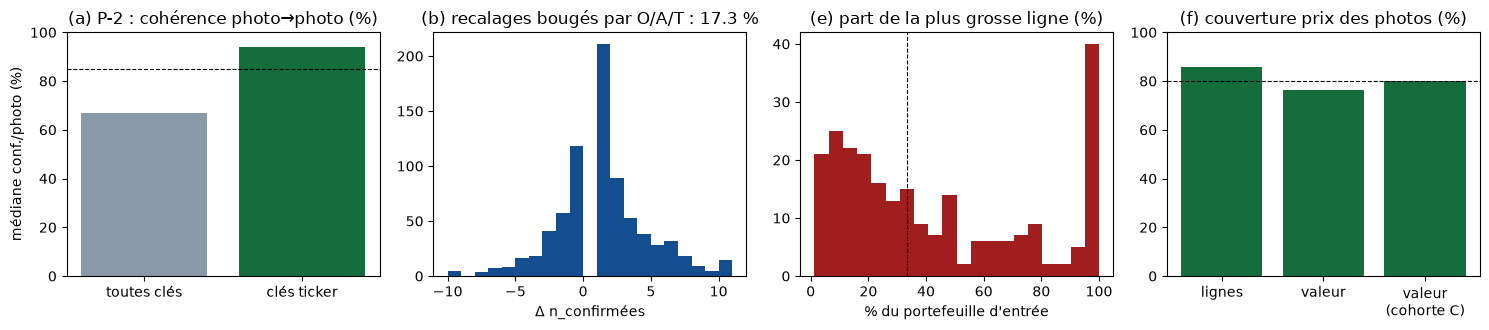

In [22]:
# Figure de synthèse des gates (fig_10_gates.png)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
ax = axes[0]
ax.bar(["toutes clés", "clés ticker"], [66.7, P2_TICKER], color=["#8899aa", "#146e3c"])
ax.axhline(85, ls="--", c="k", lw=.8); ax.set_ylim(0, 100)
ax.set_title("(a) P-2 : cohérence photo→photo (%)"); ax.set_ylabel("médiane conf./photo (%)")
ax = axes[1]
ax.hist(_delta[_delta != 0], bins=range(-10, 12), color="#144d90")
ax.set_title(f"(b) recalages bougés par O/A/T : {PART_BOUGE:.1f} %"); ax.set_xlabel("Δ n_confirmées")
ax = axes[2]
ax.hist(_bmax * 100, bins=20, color="#a01e1e")
ax.axvline(_bmax.median() * 100, ls="--", c="k", lw=.8)
ax.set_title("(e) part de la plus grosse ligne (%)"); ax.set_xlabel("% du portefeuille d'entrée")
ax = axes[3]
ax.bar(["lignes", "valeur", "valeur\n(cohorte C)"], [_cov_l, _cov_v, _cov_v73], color="#146e3c")
ax.axhline(80, ls="--", c="k", lw=.8); ax.set_ylim(0, 100)
ax.set_title("(f) couverture prix des photos (%)")
plt.tight_layout()
os.makedirs(os.path.join(BASE, "figures"), exist_ok=True)
plt.savefig(os.path.join(BASE, "figures", "fig_10_gates.png"), dpi=130, bbox_inches="tight")
plt.show()

### 2.1 Validation §2 — verdicts mécaniques des gates

La cellule suivante applique les règles du GEL aux mesures — aucun jugement discrétionnaire.

In [23]:
_verdicts = {
    "(a) P-2_ticker":        (P2_TICKER, "≥85 → h₀ tel quel ; 70-85 → recalage O obligatoire ; <70 → fermé",
                              "h₀ tel quel, recalage O = audit" if P2_TICKER >= 85
                              else ("recalage O obligatoire" if P2_TICKER >= 70 else "E2-h₀ FERMÉ")),
    "(b) part bougée O/A/T": (PART_BOUGE, "≥5 % → run F candidat",
                              "run F dans l'ablation" if PART_BOUGE >= 5 else "run F fermé"),
    "(c) cohorte":           (len(C_ENTREE), "≥30", "OUVERT" if len(C_ENTREE) >= 30 else "FERMÉ"),
    "(d) MDE NAV (%/an)":    (round(_MDE_NAV * 100, 1), ">5 → jugement au classement", "ΔIC apparié obligatoire"),
    "(e) part max médiane":  (round(_bmax.median() * 100), ">25 % → sensibilité obligatoire",
                              "sensibilité {lo,mid,hi} obligatoire" if _bmax.median() > .25 else "recommandée"),
    "(f) couverture valeur": (round(_cov_v, 1), "≥80 %", "OK" if _cov_v >= 80 else "biais de survie documenté"),
    "(g) valeur tickérisée": (round(_part_tick, 1), "≥50 % pour ouvrir H2", "H2 FERMÉ" if _part_tick < 50 else "ouvert"),
}
_t = pd.DataFrame(_verdicts, index=["mesure", "règle (GEL)", "verdict"]).T
display(_t)
print("→ branches ouvertes :  E1 (inconditionnel) · E2 runs B/C/E"
      + ("/D(audit)" if P2_TICKER >= 85 else "/D(obligatoire)")
      + ("/F" if PART_BOUGE >= 5 else "") + "\n→ branches fermées :  copier le stock agrégé (g) · "
      "flux annuel-seul en événements (mécanisme réfuté : lag 374 j + placebo P1 du 08)")

,mesure,règle (GEL),verdict
(a) P-2_ticker,94.117647,≥85 → h₀ tel quel ; 70-85 → recalage O obligat...,"h₀ tel quel, recalage O = audit"
(b) part bougée O/A/T,17.276936,≥5 % → run F candidat,run F dans l'ablation
(c) cohorte,73,≥30,OUVERT
(d) MDE NAV (%/an),7.3,>5 → jugement au classement,ΔIC apparié obligatoire
(e) part max médiane,33,>25 % → sensibilité obligatoire,"sensibilité {lo,mid,hi} obligatoire"
(f) couverture valeur,76.4,≥80 %,biais de survie documenté
(g) valeur tickérisée,17.8,≥50 % pour ouvrir H2,H2 FERMÉ


→ branches ouvertes :  E1 (inconditionnel) · E2 runs B/C/E/D(audit)/F
→ branches fermées :  copier le stock agrégé (g) · flux annuel-seul en événements (mécanisme réfuté : lag 374 j + placebo P1 du 08)


## 3. E1 — event study « ventes héritées » : PRÉ-ENREGISTREMENT (GEL)

**Hypothèse économique (la seule neuve du chantier).** Le moteur P-only est structurellement aveugle au
timing des ventes du patrimoine *hérité* (h part de 0 : la vente d'une position d'entrée est tronquée).
Si l'information privée des élus existe, elle peut vivre là : *savoir quand sortir de ce qu'on possédait déjà*.

**Définitions.**
- Φ₀(m) = ensemble des tickers (ticker_yahoo) de la photo d'entrée du membre m (table 15 ⋈ 11, holdings
  tickérisés valorisés) ; f₀(m) = FilingDate de cette photo.
- Ventes PTR du périmètre 05b (df, op = "sell", House) partitionnées :
  **S_h** = {(m, i, t) : i ∈ Φ₀(m), t > f₀(m)} (ventes *héritées* — le ticker figurait dans la photo d'entrée
  et la photo est déjà publiée) ; **S_a** = ventes des mêmes membres dont le ticker ∉ Φ₀(m).
  Cohorte = membres avec photo d'entrée exploitable ∧ ≥ 1 vente dans chaque mesure d'ensemble publiée.
- Chaque vente entre au **close de J+1 de sa disclosure_date** (règle du 06 — date propre, médiane 27 j).

**Test primaire (calendar-time, une seule cellule de grille).**
R_h(t) et R_a(t) = rendements quotidiens des portefeuilles égal-pondérés des tickers en fenêtre post-vente
active (de J+1 divulgation à +252 séances) ; D(t) = R_h(t) − R_a(t) ;
régression D(t) = α_D + β·MKT_RF + s·SMB + h·HML + m·UMD + ε(t) (Carhart-4, Newey-West L = 21).
Direction attendue si talent : les titres vendus-hérités sous-performent après la vente → **α_D < 0**.

**Décision (GEL).**
- GO si t(α_D) ≤ −2,0 **et** placebo p ≤ 0,05 ;
- TOST : si IC 90 % de α_D ⊂ (−2 %/an, +2 %/an) → « équivalent à zéro », porte fermée avec borne ;
- sinon : NO-GO simple (non conclusif, documenté).
- Placebo : B = 1 000 permutations du label hérité/acquis **au niveau membre** (préserve la corrélation
  intra-membre) ; p = part des |t| permutés ≥ |t| observé.
- Fenêtres secondaires (descriptives, hors décision) : CAR médian à 63 et 126 séances.

*Aucune cellule de résultat E1 n'est exécutée avant validation du GEL (point d'arrêt ②).*

## 4. E2 — moteur 05b′ : PRÉ-ENREGISTREMENT (GEL)

**Moteur.** `member_shares_v2(g, photos, mode, h0, recal, mandat)` — état h(m, i, t) en parts :
- `mode ∈ {exec, disclosure}` : date d'effet d'un trade = τ(traded) (réplique 05b) ou τ(disclosure_date)
  avec exécution au prix P(τ(disclosure_date)) — pour un copieur, l'info ET le prix n'existent qu'à la
  divulgation ;
- `h0` : à f₀ = FilingDate de la photo d'entrée, injection h₀(m,i) = mid_i ∕ P(i, τ(f₀)) **puis rejeu des
  trades PTR divulgués dans (date_photo, f₀]** (règle anti-look-ahead : l'état injecté à f₀ est l'état
  *à la date de photo*, avancé des flux déjà publics) ; la propriété « un apport n'est jamais un rendement »
  du time-weighted (parts de la veille) couvre l'injection ;
- `recal` : aux photos O suivantes, à LEUR FilingDate, clés-ticker : recalage h := mid∕P seulement si
  h·P ∉ [lo, hi] (gate (a) ≥ 85 % → recalage en mode AUDIT : écarts journalisés, pas de correction dans le
  run principal) ;
- `mandat` : série active bornée à la fenêtre de mandat (publique en temps réel) — remplace la « liquidation
  au T » (le T arrive ~374 j trop tard).

**Ablation (GEL) — chaque effet isolé, dans cet ordre :**

| run | définition | rôle |
|---|---|---|
| A | mode exec, tout OFF | témoin : doit reproduire **bit-à-bit** les 266 séries du 05b |
| B | disclosure, P-only | quantifie le look-ahead du 05b seul — inconditionnel |
| C | B + h₀ (photos d'entrée) | l'effet des conditions initiales |
| D | C + recalages O (audit ; correction seulement si gate (a) < 85) | l'effet du stock annuel |
| E | D + fenêtres de mandat | hygiène d'univers |
| F | E + flux O/A/T net (16_flux_oat_net, à disclosure) | ouvert par le gate (b) — flux froid, attendu ≈ 0 |

**Jugement (GEL).**
- **Test central apparié intra-membre** sur la cohorte C (gate (c)) : pour Y = 2016…2025, classement par
  Sharpe expanding ≤ 31/12/Y (info disponible à la coupe : disclosure ≤ 31/12/Y), excès réalisé Y+1 ;
  IC_Y = Spearman(rang, excès) ; IC = moyenne des IC_Y pondérée par n ; **ΔIC = IC(run X) − IC(run A)**,
  IC 95 % par bootstrap par blocs (rééchantillonnage des membres, B = 2 000). GO si IC 95 % de ΔIC exclut 0.
- **Placebo photos-permutées** : B = 200 réassignations des photos d'entrée entre membres de la cohorte
  (mêmes dates) ; si Δ(permuté) ≈ Δ(vrai), l'effet est un artefact de disponibilité.
- **Sensibilité conventions** : run C rejoué avec h₀ ∈ {lo, hi} — un classement non stable sous les trois
  conventions n'est pas un résultat.
- **Top-K à réglages hérités** (K = 4, coupes annuelles, IR t > 1,645 — zéro ré-optimisation) sur A vs E :
  Δ excès publié avec sa MDE (gate (d)) — descriptif, jamais décisionnel seul.
- Interdit par protocole : tout top-K mixte (membres initialisés + non initialisables) — artefact de
  disponibilité (chambre, ancienneté).

*Aucune cellule de résultat E2 n'est exécutée avant validation du GEL (point d'arrêt ②).*

## 5. Résultats — *section verrouillée*

**Point d'arrêt ② (protocole 08).** Les sections de résultats de E1 et E2 ne sont ouvertes qu'après
validation du pré-enregistrement (§3, §4) par Alice. À l'ouverture : la MDE appariée exacte du ΔIC
(bootstrap sur le run A) est publiée AVANT le dévoilement des runs C-F ; puis les verdicts sont appliqués
mécaniquement, et la carte complète des essais (y compris les grilles déjà brûlées par 05b §14.2 et 08)
alimente le DSR global.

In [24]:
# Garde-fou final — prices_v2 n'a pas bougé (snapshot du §0)
assert sorted(os.listdir(PRICES_V2)) == _SNAP_PV2, "prices_v2 a été modifié — INTERDIT"
print(f"✅ prices_v2 intact ({len(_SNAP_PV2)} fichiers) — les oracles du 05b/07/09 restent valides")
print("Notebook §0-§4 : GELS posés, gates mesurés, moteur re-prouvé. En attente du point d'arrêt ①/②.")

✅ prices_v2 intact (3351 fichiers) — les oracles du 05b/07/09 restent valides
Notebook §0-§4 : GELS posés, gates mesurés, moteur re-prouvé. En attente du point d'arrêt ①/②.
